In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/sudan.csv')

In [2]:
# Missing values report
print("=" * 50)
print("MISSING VALUES REPORT")
print("=" * 50)

missing_count = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent': missing_percent.round(2)
})

print(missing_report[missing_report['Missing Count'] > 0])

if missing_report[missing_report['Missing Count'] > 0].empty:
    print("\n✅ No missing values found!")

MISSING VALUES REPORT
Empty DataFrame
Columns: [Missing Count, Missing Percent]
Index: []

✅ No missing values found!


In [3]:
# Distribution overview
print("\n" + "=" * 50)
print("DISTRIBUTION OVERVIEW")
print("=" * 50)

key_vars = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']
print(df[key_vars].describe().round(2))


DISTRIBUTION OVERVIEW
           T2M  T2M_MAX  T2M_MIN  PRECTOTCORR     RH2M
count  4108.00  4108.00  4108.00      4108.00  4108.00
mean     28.76    36.77    21.51         0.64    31.36
std       4.68     4.40     5.09         3.06    17.85
min      13.18    21.04     5.93         0.00     4.69
25%      25.56    33.73    17.50         0.00    17.41
50%      29.16    37.02    22.89         0.00    26.63
75%      32.51    40.33    25.43         0.01    40.53
max      37.99    45.96    32.17        66.49    87.16


In [4]:
df = df.replace(-999, np.nan)
df['Country'] = 'Sudan'
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')
df['Month'] = df['Date'].dt.month

print(f"Sudan data loaded: {df.shape[0]} rows")
df.head()

Sudan data loaded: 4108 rows


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1



Outliers (|Z| > 3):
T2M: 3
T2M_MAX: 6
T2M_MIN: 1
PRECTOTCORR: 71
RH2M: 3
WS2M: 4
WS2M_MAX: 3


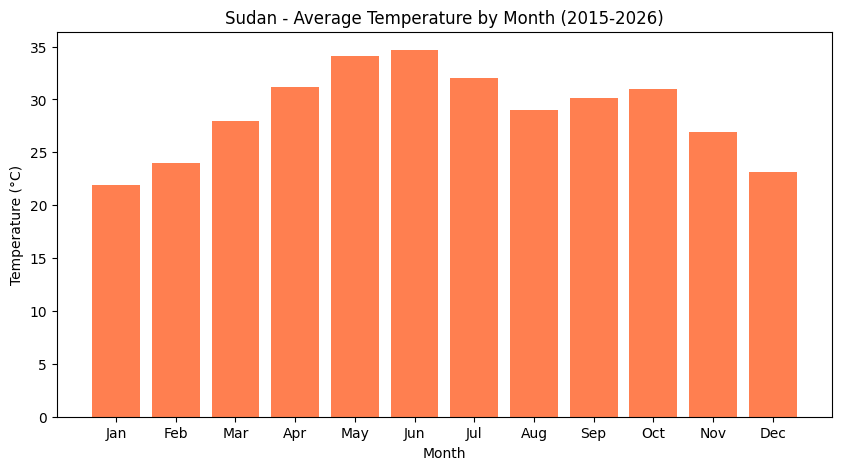

Warmest month: 6 (34.7°C)
Coolest month: 1 (21.9°C)


In [5]:
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
print("\nOutliers (|Z| > 3):")
for col in weather_cols:
    z_scores = (df[col] - df[col].mean()) / df[col].std()
    outliers = (abs(z_scores) > 3).sum()
    print(f"{col}: {outliers}")


monthly_avg = df.groupby('Month')['T2M'].mean()
plt.figure(figsize=(10, 5))
plt.bar(monthly_avg.index, monthly_avg.values, color='coral')
plt.title('Sudan - Average Temperature by Month (2015-2026)')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()
print(f"Warmest month: {monthly_avg.idxmax()} ({monthly_avg.max():.1f}°C)")
print(f"Coolest month: {monthly_avg.idxmin()} ({monthly_avg.min():.1f}°C)")

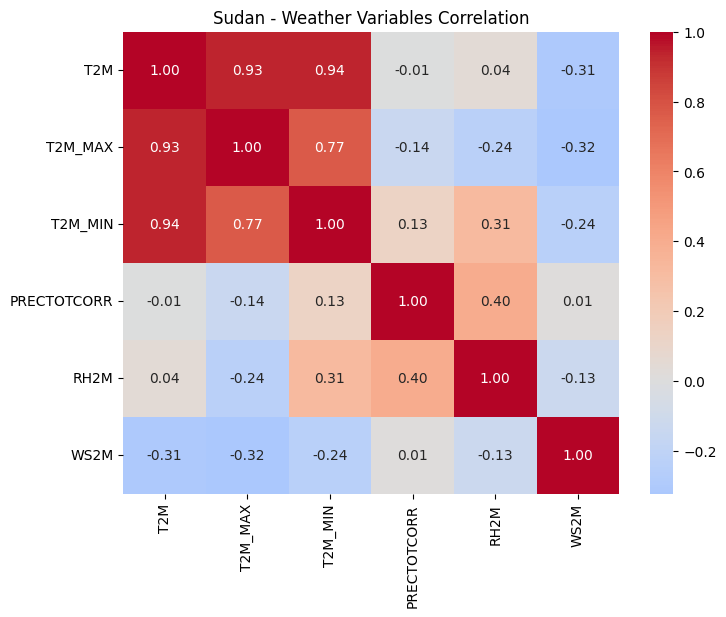


Strongest correlations (|r| > 0.5):
T2M vs T2M_MAX: 0.93
T2M vs T2M_MIN: 0.94
T2M_MAX vs T2M_MIN: 0.77


In [6]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Sudan - Weather Variables Correlation')
plt.show()

corr_matrix = df[numeric_cols].corr()
print("\nStrongest correlations (|r| > 0.5):")
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            print(f"{corr_matrix.columns[i]} vs {corr_matrix.columns[j]}: {corr_value:.2f}")

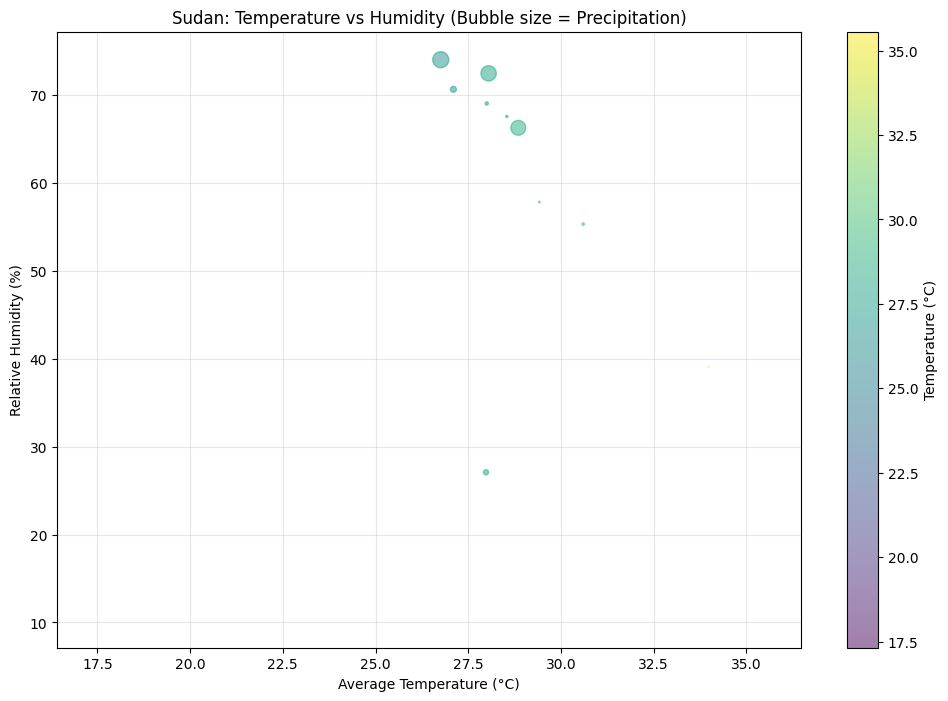

In [7]:
sample = df.iloc[::100, :]
plt.figure(figsize=(12, 8))
scatter = plt.scatter(sample['T2M'], sample['RH2M'], 
                      s=sample['PRECTOTCORR']*10, alpha=0.5, c=sample['T2M'], cmap='viridis')
plt.colorbar(label='Temperature (°C)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Sudan: Temperature vs Humidity (Bubble size = Precipitation)')
plt.grid(True, alpha=0.3)
plt.show()

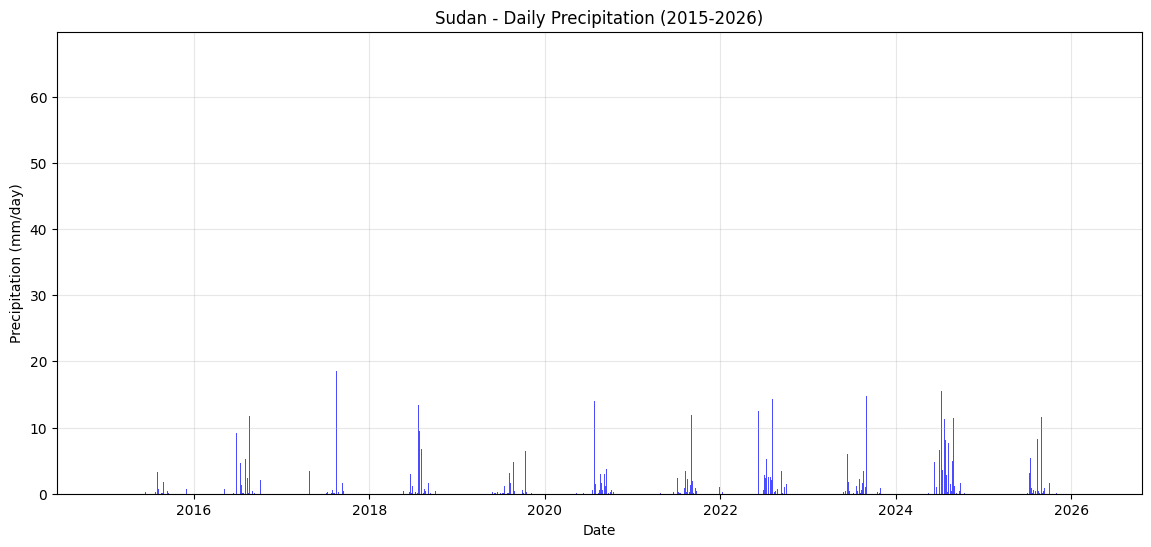

In [8]:
monthly_rain = df.groupby('Date')['PRECTOTCORR'].sum()
plt.figure(figsize=(14, 6))
plt.bar(monthly_rain.index, monthly_rain.values, color='blue', alpha=0.7)
plt.title('Sudan - Daily Precipitation (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm/day)')
plt.grid(True, alpha=0.3)
plt.show()

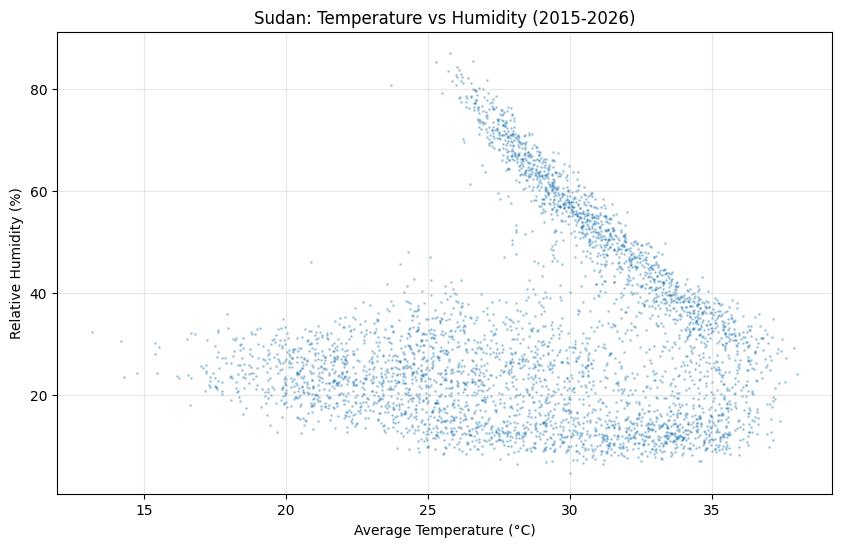

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M'], df['RH2M'], alpha=0.3, s=1)
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Sudan: Temperature vs Humidity (2015-2026)')
plt.grid(True, alpha=0.3)
plt.show()

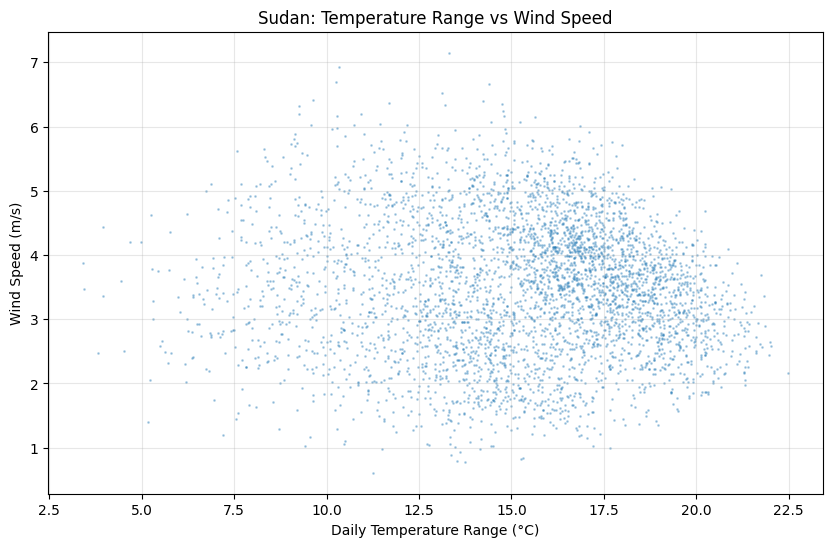

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, s=1)
plt.xlabel('Daily Temperature Range (°C)')
plt.ylabel('Wind Speed (m/s)')
plt.title('Sudan: Temperature Range vs Wind Speed')
plt.grid(True, alpha=0.3)
plt.show()

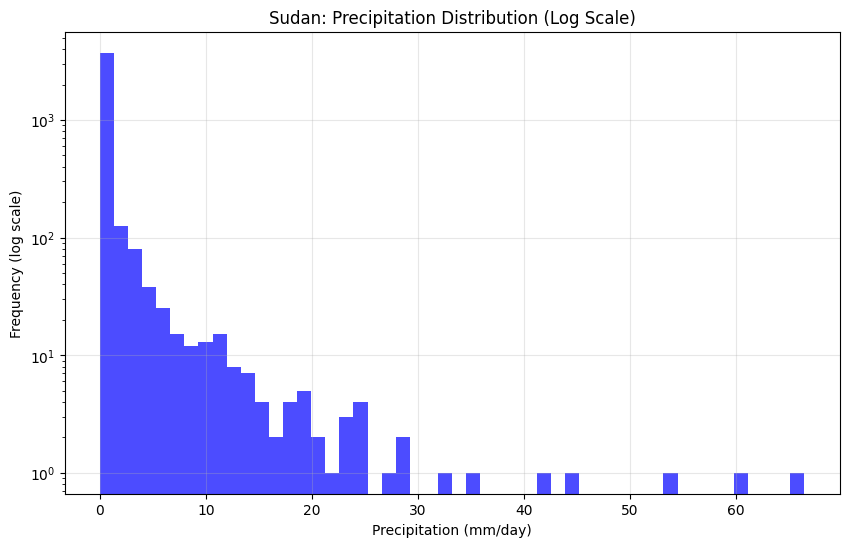

In [11]:
import numpy as np
plt.figure(figsize=(10, 6))
plt.hist(df['PRECTOTCORR'], bins=50, alpha=0.7, color='blue')
plt.yscale('log')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Frequency (log scale)')
plt.title('Sudan: Precipitation Distribution (Log Scale)')
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
df.to_csv('../data/sudan_clean.csv', index=False)
print("Saved to data/sudan_clean.csv")

Saved to data/sudan_clean.csv
